Pre-Actividad
(Practicar syntax)

In [1]:
import yfinance as yf

microsoft = yf.Ticker("MSFT")
hist = microsoft.history(period="1d")
print("precio de apertura", float(hist["Open"].iloc[-1]))
print("precio actual", float(microsoft.fast_info["last_price"]))

precio de apertura 400.7200012207031
precio actual 395.54998779296875


Para obtener los precios historicos

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
import yfinance as yf

2026-03-13 16:18:56.159483: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
from pathlib import Path


def get_prices(share_symbol, start_date, end_date, cache_filename):
    cache_path = Path(cache_filename)

    try:
        return np.load(cache_path).tolist()
    except FileNotFoundError:
        ticker = yf.Ticker(share_symbol)
        stock_hist = ticker.history(start=start_date, end=end_date)

        stock_prices = stock_hist["Open"].dropna().to_numpy(dtype=float)

        cache_path.parent.mkdir(parents=True, exist_ok=True)  # prob se puede arr
        np.save(cache_path, stock_prices)

        return stock_prices.tolist()

Para Graficar

In [10]:
import matplotlib.pyplot as plt

def plot_prices(prices):
    plt.title("Opening stock prices")
    plt.xlabel("day")
    plt.ylabel("price ($)")
    plt.plot(prices)
    plt.show()

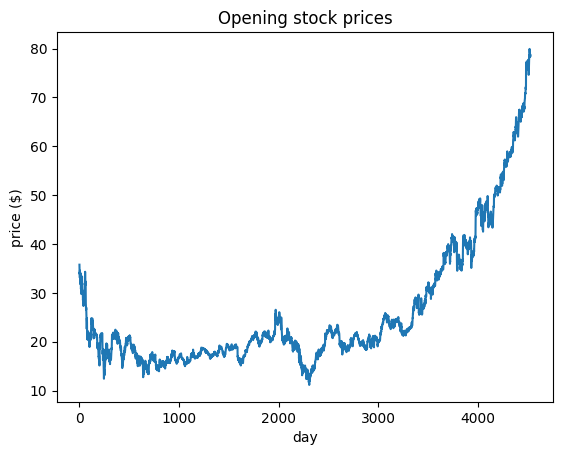

In [11]:
prices = get_prices('MSFT', '2000-01-01', '2017-12-31', 'msft_prices.npy')
plot_prices(prices)


Def Politicas de Decision

In [13]:
class DecisionPolicy:
    def select_action(self, current_state, step):
        pass

    def update_q(self, state, action, reward, next_state):
        pass


class RandomDecisionPolicy(DecisionPolicy):
    def __init__(self, actions):
        self.actions = actions

    def select_action(self, current_state, step):
        action = self.actions[random.randint(0, len(self.actions) - 1)]
        return action

Simulaciones del Agente

In [25]:
def run_simulation(policy, initial_budget, initial_num_stocks, prices, hist, debug=False):
    budget = initial_budget
    num_stocks = initial_num_stocks
    share_value = 0
    transitions = list()

    for i in range(len(prices) - hist - 1):
        if i % 100 == 0:
            print('progress {:.2f}%'.format(float(100 * i) / (len(prices) - hist - 1)))

        current_state = np.asmatrix(np.hstack((prices[i:i+hist], budget, num_stocks)))
        current_portfolio = budget + num_stocks * float(prices[i+hist])

        action = policy.select_action(current_state, i)
        share_value = float(prices[i+hist + 1])

        if action == 'Buy' and budget >= share_value:
            budget -= share_value
            num_stocks += 1
        elif action == 'Sell' and num_stocks > 0:
            budget += share_value
            num_stocks -= 1
        else:
            action = 'Hold'

        new_portfolio = budget + num_stocks * share_value
        reward = new_portfolio - current_portfolio

        next_state = np.asmatrix(np.hstack((prices[i+1:i+hist+1], budget, num_stocks)))
        transitions.append((current_state, action, reward, next_state))
        policy.update_q(current_state, action, reward, next_state)

    portfolio = budget + num_stocks * share_value
    if debug:
        print('${}\t{} shares'.format(budget, num_stocks))
    return portfolio

def run_simulations(policy, budget, num_stocks, prices, hist):
    num_tries = 100
    final_portfolios = []
    for _ in range(num_tries):
        final_portfolios.append(run_simulation(policy, budget, num_stocks, prices, hist))
    return float(np.mean(final_portfolios)), float(np.std(final_portfolios))

Agente de Q-Learning usando Tenserflow

In [29]:
tf.compat.v1.disable_eager_execution()


class QLearningDecisionPolicy(DecisionPolicy):
    def __init__(self, actions, input_dim):
        self.epsilon = 0.9
        self.gamma = 0.001
        self.actions = actions
        output_dim = len(actions)
        h1_dim = 200

        self.x = tf.compat.v1.placeholder(tf.float32, [None, input_dim])
        self.y = tf.compat.v1.placeholder(tf.float32, [None, output_dim])

        W1 = tf.Variable(tf.random.normal([input_dim, h1_dim]))
        b1 = tf.Variable(tf.constant(0.1, shape=[h1_dim]))
        h1 = tf.nn.relu(tf.matmul(self.x, W1) + b1)

        W2 = tf.Variable(tf.random.normal([h1_dim, output_dim]))
        b2 = tf.Variable(tf.constant(0.1, shape=[output_dim]))
        self.q = tf.matmul(h1, W2) + b2

        loss = tf.reduce_mean(tf.square(self.y - self.q))
        self.train_op = tf.compat.v1.train.GradientDescentOptimizer(0.01).minimize(loss)

        self.sess = tf.compat.v1.Session()
        self.sess.run(tf.compat.v1.global_variables_initializer())

    def select_action(self, current_state, step):
        threshold = min(self.epsilon, step / 1000.0)
        if random.random() < threshold:
            action_q_vals = self.sess.run(self.q, feed_dict={self.x: current_state})
            action_idx = int(np.argmax(action_q_vals))
            action = self.actions[action_idx]
        else:
            action = self.actions[random.randint(0, len(self.actions) - 1)]
        return action

    def update_q(self, state, action, reward, next_state):
        action_idx = self.actions.index(action)

        q_vals = self.sess.run(self.q, feed_dict={self.x: state})
        next_q_vals = self.sess.run(self.q, feed_dict={self.x: next_state})

        target = np.array(q_vals, copy=True)
        target[0, action_idx] = reward + self.gamma * float(np.max(next_q_vals))

        self.sess.run(self.train_op, feed_dict={self.x: state, self.y: target})

Bloque Principal de Ejecución

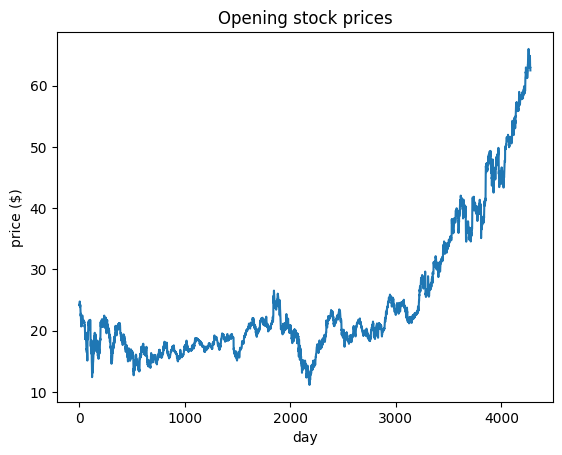

progress 0.00%
progress 2.45%
progress 4.91%
progress 7.36%
progress 9.82%
progress 12.27%
progress 14.72%
progress 17.18%
progress 19.63%
progress 22.09%
progress 24.54%
progress 26.99%
progress 29.45%
progress 31.90%
progress 34.36%
progress 36.81%
progress 39.26%
progress 41.72%
progress 44.17%
progress 46.63%
progress 49.08%
progress 51.53%
progress 53.99%
progress 56.44%
progress 58.90%
progress 61.35%
progress 63.80%
progress 66.26%
progress 68.71%
progress 71.17%
progress 73.62%
progress 76.07%
progress 78.53%
progress 80.98%
progress 83.44%
progress 85.89%
progress 88.34%
progress 90.80%
progress 93.25%
progress 95.71%
progress 98.16%
progress 0.00%
progress 2.45%
progress 4.91%
progress 7.36%
progress 9.82%
progress 12.27%
progress 14.72%
progress 17.18%
progress 19.63%
progress 22.09%
progress 24.54%
progress 26.99%
progress 29.45%
progress 31.90%
progress 34.36%
progress 36.81%
progress 39.26%
progress 41.72%
progress 44.17%
progress 46.63%
progress 49.08%
progress 51.53%
pr

In [30]:

prices = get_prices("MSFT", "2000-07-01", "2017-07-01", "historical_stock_prices.npy")
plot_prices(prices)

actions = ["Buy", "Sell", "Hold"]
hist = 200
policy = RandomDecisionPolicy(actions)
budget = 1000.0
num_stocks = 0

avg, std = run_simulations(policy, budget, num_stocks, prices, hist)
print(f"Promedio: {avg}, Desviación Estándar: {std}")

Cambios del Codigo 

Primero se copio directamente el mismo codigo del pdf de la actividad. Por lo tanto, al correrlo habia problemas ocurrentes por todo el codigo. Todo fue en parte de la libreria de yahoo_finance (fue cambiado por la lib yfinance) = esta libreria quedo a cierto punto obsoleto por su viejes, y creó problemas en el programa. Por eso utilize yfinance, siendo la libreria que se usa hoy en dia.

Por esto, se tuvo que hacer otros cambios:

* Clase Principal = Share('MSFT') cambiado por yf.Ticker('MSFT')
* Hist Data = .get_historical(start, end) a .history(start=..., end=...)
* Price Access = float(data['Open']) a df['Open'], siendo que ya es un float 

(son todos que he notado por el momento, pueden haber mas, pero detalles pequeñas)